# Web Table Extraction with pandas

This notebook extracts historical box-office tables from the web, converts currency fields to numeric values, and visualizes relationships between revenue and time in theaters.

## Box Office Mojo tables

[pandas `read_html`](https://pandas.pydata.org/docs/reference/api/pandas.read_html.html) can extract structured HTML tables directly into DataFrames. The source is [Box Office Mojo](https://www.boxofficemojo.com), whose `robots.txt` file should be reviewed before automated access.

The first example uses the [January 6–8, 2023 weekend chart](https://www.boxofficemojo.com/weekend/2023W01/).

In [2]:
import pandas as pd

tables = pd.read_html("https://www.boxofficemojo.com/weekend/2023W01/")

`read_html` returns a list of tables discovered on the page. The number of results is checked before selecting a table.

In [3]:
len(tables)

1

The extracted tables are inspected to identify the box-office data.

In [4]:
for t in tables:
    display(t.head())

,Rank,LW,Release,Gross,%± LW,Theaters,Change,Average,Total Gross,Weeks,Distributor,New This Week,Estimated
0,1,1,Avatar: The Way of Water,"$45,838,986",-32%,4340,+138,"$10,561","$517,628,365",4,20th Century Studios,False,False
1,2,-,M3GAN,"$30,429,860",-,3509,-,"$8,671","$30,429,860",1,Universal Pictures,True,False
2,3,2,Puss in Boots: The Last Wish,"$13,541,330",-19.5%,3919,-202,"$3,455","$88,127,165",3,Universal Pictures,False,False
3,4,18,A Man Called Otto,"$4,202,386","+7,370%",637,+633,"$6,597","$4,287,866",2,Columbia Pictures,False,False
4,5,3,Black Panther: Wakanda Forever,"$3,523,456",-31.5%,2255,-55,"$1,562","$445,563,072",9,Walt Disney Studios Motion Pictures,False,False


The page contains one relevant table, which is selected for analysis.

In [5]:
movieData = tables[0]

movieData.head()

,Rank,LW,Release,Gross,%± LW,Theaters,Change,Average,Total Gross,Weeks,Distributor,New This Week,Estimated
0,1,1,Avatar: The Way of Water,"$45,838,986",-32%,4340,+138,"$10,561","$517,628,365",4,20th Century Studios,False,False
1,2,-,M3GAN,"$30,429,860",-,3509,-,"$8,671","$30,429,860",1,Universal Pictures,True,False
2,3,2,Puss in Boots: The Last Wish,"$13,541,330",-19.5%,3919,-202,"$3,455","$88,127,165",3,Universal Pictures,False,False
3,4,18,A Man Called Otto,"$4,202,386","+7,370%",637,+633,"$6,597","$4,287,866",2,Columbia Pictures,False,False
4,5,3,Black Panther: Wakanda Forever,"$3,523,456",-31.5%,2255,-55,"$1,562","$445,563,072",9,Walt Disney Studios Motion Pictures,False,False


## Prepare numeric columns

`Gross` and `Total Gross` contain currency symbols and thousands separators, so they must be cleaned and converted to numeric values before plotting.

In [6]:
# Inspect column data types before conversion
movieData.dtypes

Rank              int64
LW               object
Release          object
Gross            object
%± LW            object
Theaters          int64
Change           object
Average          object
Total Gross      object
Weeks             int64
Distributor      object
New This Week      bool
Estimated          bool
dtype: object

In [7]:
# Remove currency formatting and convert Gross to a numeric type
movieData["Gross"].replace('[\$,]', '', regex=True, inplace=True)
movieData["Gross"] = movieData["Gross"].apply(pd.to_numeric)

# Apply the same conversion to Total Gross
movieData["Total Gross"].replace('[\$,]', '', regex=True, inplace=True)
movieData["Total Gross"] = movieData["Total Gross"].apply(pd.to_numeric)

movieData.dtypes

Rank              int64
LW               object
Release          object
Gross             int64
%± LW            object
Theaters          int64
Change           object
Average          object
Total Gross       int64
Weeks             int64
Distributor      object
New This Week      bool
Estimated          bool
dtype: object

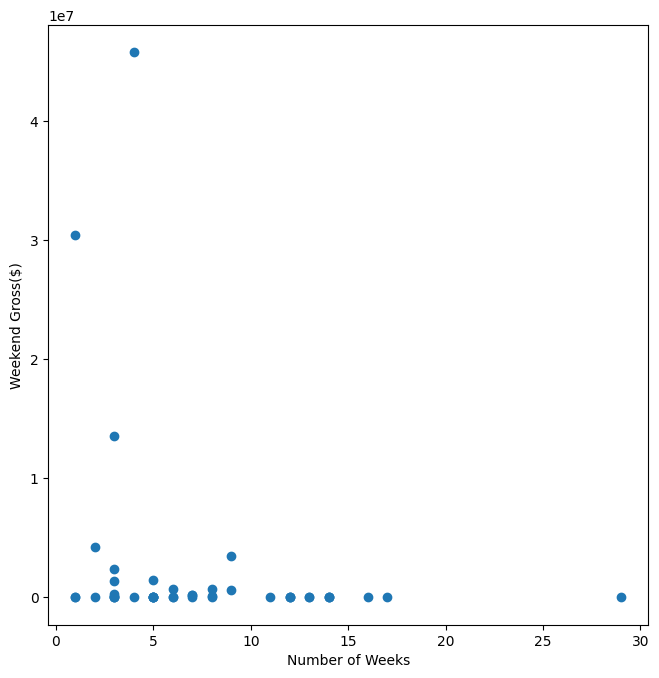

In [8]:
%matplotlib inline
import matplotlib.pyplot as plt

fig1 = plt.figure(figsize=(6,6))
fig1_axes=fig1.add_axes([0,0,1,1])
fig1_axes.set_ylabel('Weekend Gross(\$)')
fig1_axes.set_xlabel('Number of Weeks')

fig1_axes.scatter(x='Weeks', y='Gross', data=movieData)
fig1.show()

A second scatterplot compares total gross with the number of weeks in release.

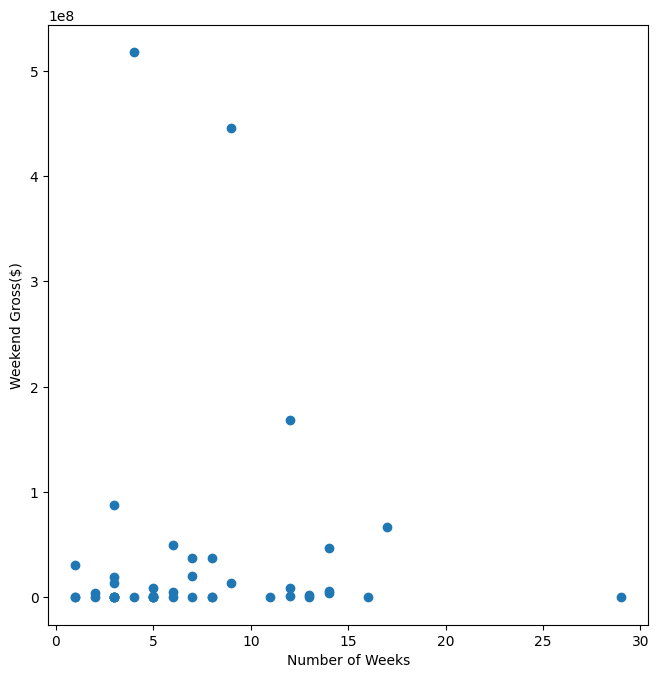

In [9]:
fig2 = plt.figure(figsize=(6,6))
fig2_axes=fig2.add_axes([0,0,1,1])
fig2_axes.set_ylabel('Weekend Gross(\$)')
fig2_axes.set_xlabel('Number of Weeks')

fig2_axes.scatter(x='Weeks', y='Total Gross', data=movieData)
fig2.show()

In [11]:
# Repeat the workflow for a March 2023 weekend



In [12]:
# Extract the page tables and inspect the result count

tables2 = pd.read_html("https://www.boxofficemojo.com/weekend/2023W26/")

len(tables2)

1

In [17]:
# Select the first table and inspect its final five rows

MovieJuly2023 = tables2[0]

display(MovieJuly2023.head())


,Rank,LW,Release,Gross,%± LW,Theaters,Change,Average,Total Gross,Weeks,Distributor,New This Week,Estimated
0,1,-,Indiana Jones and the Dial of Destiny,"$60,368,101",-,4600,-,"$13,123","$60,368,101",1,Walt Disney Studios Motion Pictures,True,False
1,2,2,Elemental,"$12,128,492",-34.2%,3650,-385,"$3,322","$89,607,297",3,Walt Disney Studios Motion Pictures,False,False
2,3,1,Spider-Man: Across the Spider-Verse,"$12,006,087",-36.8%,3405,-380,"$3,526","$340,377,908",5,Columbia Pictures,False,False
3,4,4,No Hard Feelings,"$7,857,860",-47.6%,3208,-,"$2,449","$29,668,812",2,Sony Pictures Entertainment (SPE),False,False
4,5,5,Transformers: Rise of the Beasts,"$7,353,892",-37.4%,2852,-671,"$2,578","$136,463,958",4,Paramount Pictures,False,False


In [19]:
# Clean and convert the currency columns

MovieJuly2023.dtypes

Rank              int64
LW               object
Release          object
Gross            object
%± LW            object
Theaters          int64
Change           object
Average          object
Total Gross      object
Weeks             int64
Distributor      object
New This Week      bool
Estimated          bool
dtype: object

In [20]:
MovieJuly2023["Gross"].replace('\$', ' ', regex=True, inplace=True)
MovieJuly2023["Gross"] = movieData["Gross"].apply(pd.to_numeric)

MovieJuly2023["Total Gross"].replace('\$', ' ', regex = True, inplace = True)
MovieJuly2023["Total Gross"] = MovieJuly2023["Gross"].apply(pd.to_numeric)

MovieJuly2023.dtypes

Rank              int64
LW               object
Release          object
Gross             int64
%± LW            object
Theaters          int64
Change           object
Average          object
Total Gross       int64
Weeks             int64
Distributor      object
New This Week      bool
Estimated          bool
dtype: object

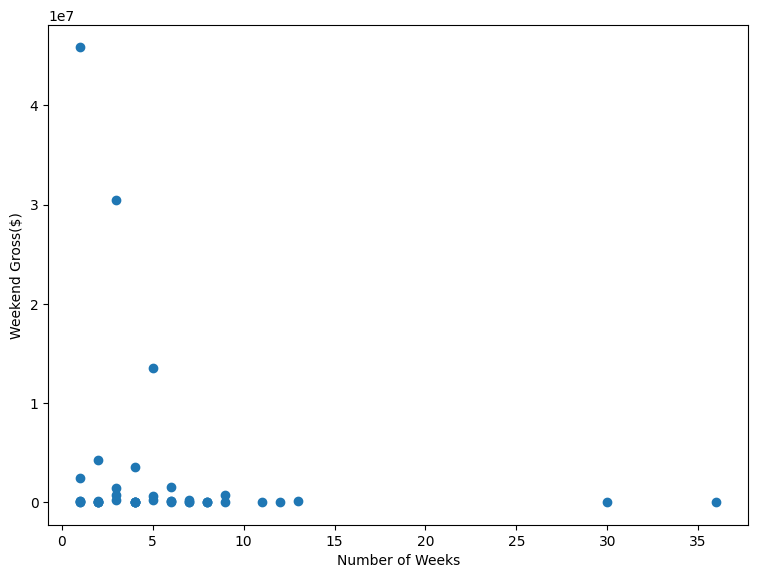

In [21]:
# Compare weekend gross with weeks in release


Fig1 = plt.figure(figsize=(7, 5))
Fig1_axes = Fig1.add_axes([0,0,1,1])
Fig1_axes.set_ylabel('Weekend Gross(\$)')
Fig1_axes.set_xlabel('Number of Weeks')

Fig1_axes.scatter(x='Weeks', y='Gross', data=MovieJuly2023)
Fig1.show()

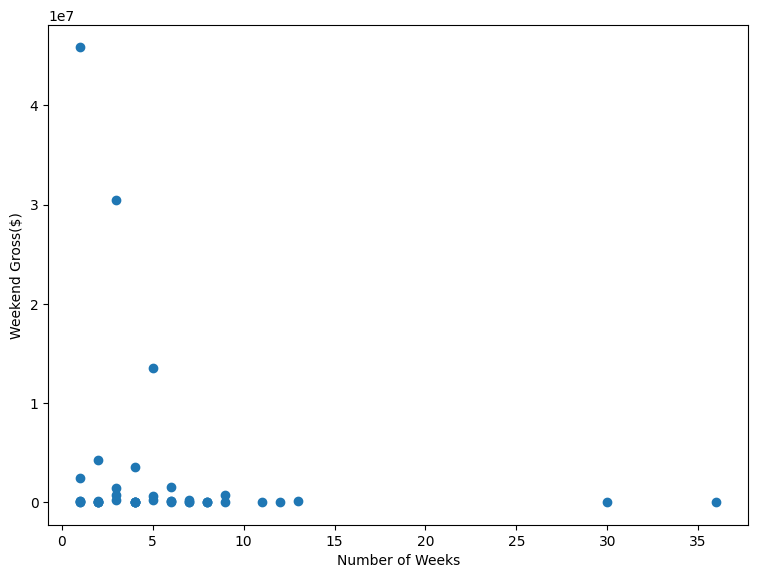

In [23]:
# Compare cumulative gross with weeks in release



Fig2 = plt.figure(figsize=(7, 5))
Fig2_axes = Fig2.add_axes([0,0,1,1])
Fig2_axes.set_ylabel('Weekend Gross(\$)')
Fig2_axes.set_xlabel('Number of Weeks')

Fig2_axes.scatter(x='Weeks', y='Total Gross', data=MovieJuly2023)
Fig2.show()